# 🛒 Customer Segmentation – RFM Analysis & KMeans Clustering
### Online Retail II Dataset (UCI / Kaggle)
**Objective:** Group customers into segments based on how recently, how often, and how much they buy.

---
## 0. 📦 Install & Import Dependencies

In [1]:
# Uncomment and run this once to install all required libraries
# !pip install pandas numpy matplotlib seaborn scikit-learn joblib openpyxl kagglehub

# Standard Python libraries
import os
import warnings

# Data handling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Machine learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Save/load model
import joblib

# Global settings
warnings.filterwarnings('ignore')                          # hide noisy warnings
sns.set_theme(style='whitegrid', palette='muted')          # consistent chart style
plt.rcParams['figure.dpi'] = 120                           # sharper figures
RANDOM_STATE = 42                                          # seed for reproducibility

print('All libraries imported successfully.')

All libraries imported successfully.


---
## 1. 📥 Data Loading

In [2]:
import kagglehub

# ── Kaggle Authentication ──────────────────────────────────────────────────
# This notebook uses the standard kaggle.json method for authentication.
# Setup (one-time):
#   1. Go to https://www.kaggle.com/settings → API → "Create New Token"
#   2. A kaggle.json file will download automatically
#   3. Place it at:
#        Windows : C:\\Users\\<YourName>\\.kaggle\\kaggle.json
#        Mac/Linux: ~/.kaggle/kaggle.json
# No token needs to be pasted here — kagglehub reads kaggle.json automatically.
# ──────────────────────────────────────────────────────────────────────────

# Download the dataset from Kaggle (only downloads once, then uses cache)
kaggle_path = kagglehub.dataset_download("mashlyn/online-retail-ii-uci")
print("Files in folder:", os.listdir(kaggle_path))

# Build the full path to the csv file
csv_file  = [f for f in os.listdir(kaggle_path) if f.endswith('.csv')][0]
DATA_PATH = os.path.join(kaggle_path, csv_file)
print(f'Loading from: {DATA_PATH}')

# Load the csv into a DataFrame
df_raw = pd.read_csv(DATA_PATH, dtype={'Customer ID': str})

print(f'\n  It Loaded {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
df_raw.head(2)

Using Colab cache for faster access to the 'online-retail-ii-uci' dataset.
Files in folder: ['online_retail_II.csv']
Loading from: /kaggle/input/online-retail-ii-uci/online_retail_II.csv

  It Loaded 1,067,371 rows × 8 columns


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom


---
## 2. 🔍 Data Validation

In [3]:
# Check the shape of the data
print(f'Rows : {df_raw.shape[0]:,}')
print(f'Cols : {df_raw.shape[1]}')

# Check data types — Quantity and Price must be numbers
print('\nData types:')
print(df_raw.dtypes)

# Count missing values per column
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
print('\n MISSING VALUES:')
print(pd.DataFrame({'count': missing, 'pct%': missing_pct}))

# Count exact duplicate rows
n_dups = df_raw.duplicated().sum()
print(f'\nDuplicate rows: {n_dups:,}')

Rows : 1,067,371
Cols : 8

Data types:
Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID     object
Country         object
dtype: object

 MISSING VALUES:
              count   pct%
Invoice           0   0.00
StockCode         0   0.00
Description    4382   0.41
Quantity          0   0.00
InvoiceDate       0   0.00
Price             0   0.00
Customer ID  243007  22.77
Country           0   0.00

Duplicate rows: 34,335


---
## 3. 📊 Exploratory Data Analysis (EDA)

In [4]:
# Basic overview of the dataset
print('=== Dataset Overview ===')
print(f'Date range       : {df_raw["InvoiceDate"].min()} → {df_raw["InvoiceDate"].max()}')
print(f'Unique customers : {df_raw["Customer ID"].nunique():,}')
print(f'Unique invoices  : {df_raw["Invoice"].nunique():,}')
print(f'Unique products  : {df_raw["StockCode"].nunique():,}')
print(f'Unique countries : {df_raw["Country"].nunique():,}')
print('\nDescriptive Statistics:')
df_raw[['Quantity', 'Price']].describe().round(2)

# Note: Negative Quantity/Price values represent returns and corrections.
# These are intentionally kept in the EDA to show the raw data shape.
# They will be removed in Section 4 (Data Cleaning).

=== Dataset Overview ===
Date range       : 2009-12-01 07:45:00 → 2011-12-09 12:50:00
Unique customers : 5,942
Unique invoices  : 53,628
Unique products  : 5,305
Unique countries : 43

Descriptive Statistics:


,Quantity,Price
count,1067371.00,1067371.00
mean,9.94,4.65
std,172.71,123.55
min,-80995.00,-53594.36
25%,1.00,1.25
50%,3.00,2.10
75%,10.00,4.15
max,80995.00,38970.00


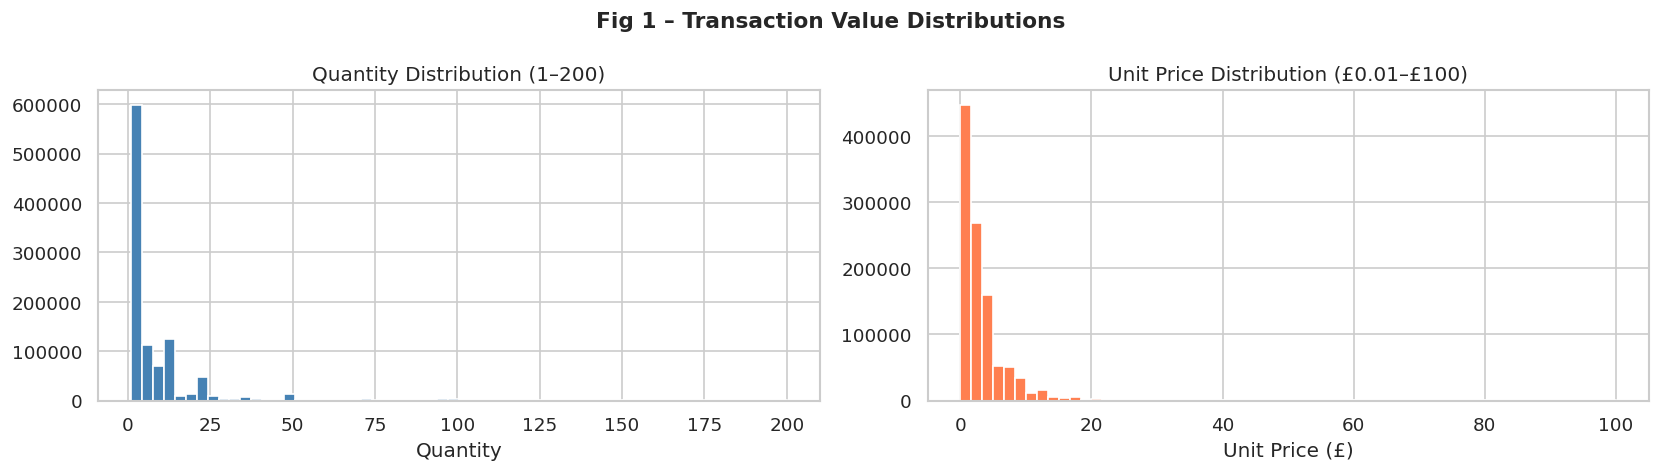

In [5]:
# Plot distribution of Quantity and Price
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Filter to readable range before plotting
qty_pos = df_raw.loc[df_raw['Quantity'].between(1, 200), 'Quantity']
axes[0].hist(qty_pos, bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Quantity Distribution (1–200)')
axes[0].set_xlabel('Quantity')

price_pos = df_raw.loc[df_raw['Price'].between(0.01, 100), 'Price']
axes[1].hist(price_pos, bins=60, color='coral', edgecolor='white')
axes[1].set_title('Unit Price Distribution (£0.01–£100)')
axes[1].set_xlabel('Unit Price (£)')

plt.suptitle('Fig 1 – Transaction Value Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_distributions.png', bbox_inches='tight')
plt.show()

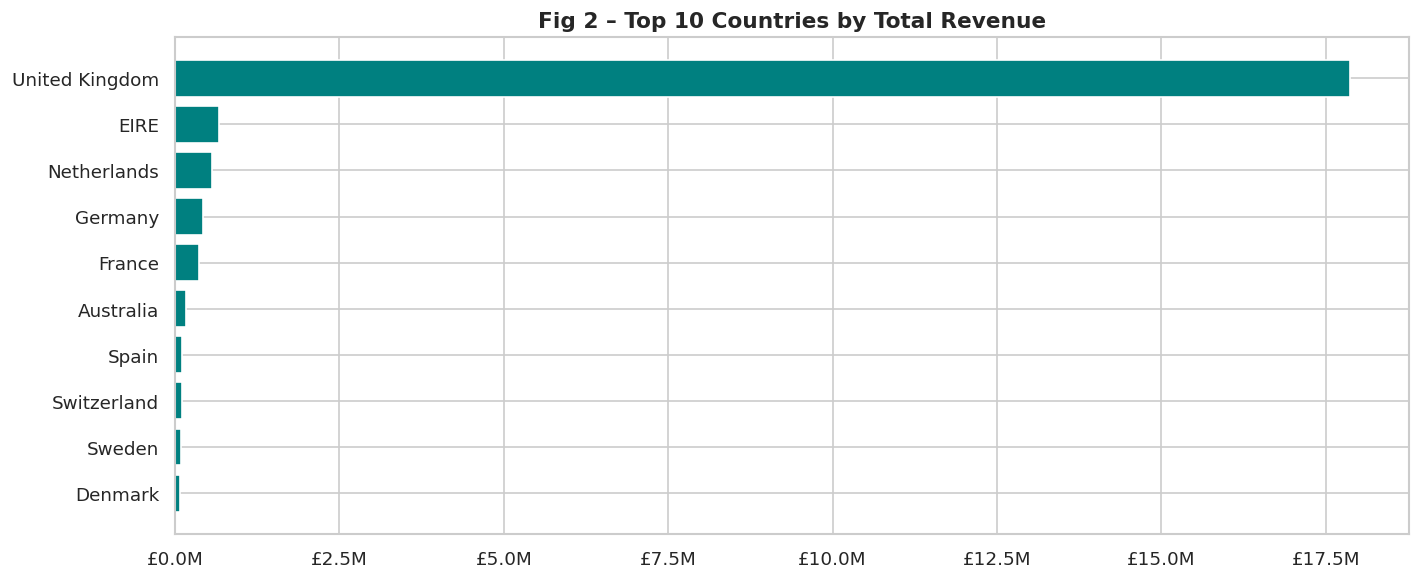

In [6]:
# Calculate revenue per row (Quantity × Price)
df_eda = df_raw.copy()
df_eda['Revenue'] = df_eda['Quantity'] * df_eda['Price']

# Top 10 countries by total revenue
top_countries = df_eda[df_eda['Revenue'] > 0].groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(top_countries.index[::-1], top_countries.values[::-1], color='teal')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M'))
ax.set_title('Fig 2 – Top 10 Countries by Total Revenue', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_top_countries.png', bbox_inches='tight')
plt.show()

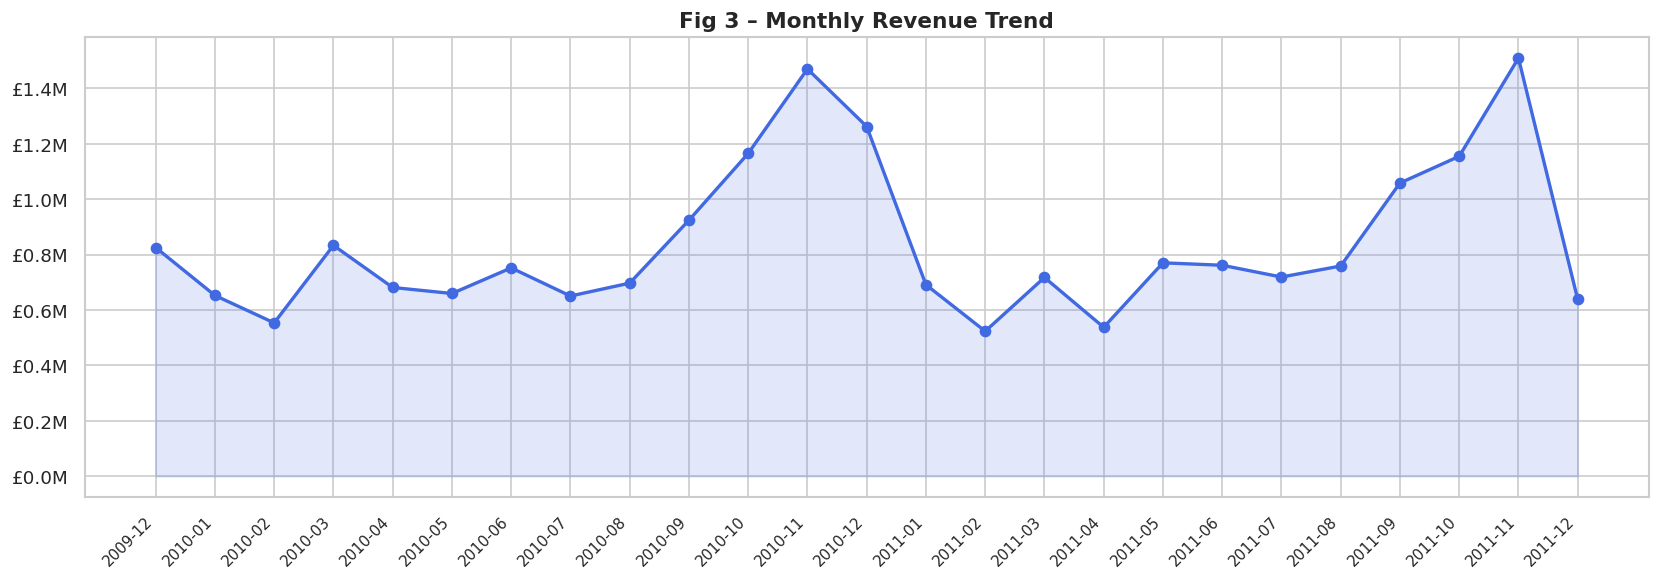

🔍 Insight: Revenue peaks in Q4 (Oct–Nov) due to holiday season effect.


In [7]:
# Monthly revenue trend
df_eda['InvoiceDate'] = pd.to_datetime(df_eda['InvoiceDate'])
df_eda['YearMonth'] = df_eda['InvoiceDate'].dt.to_period('M')

# Group by month, exclude negative revenue (returns)
monthly_revenue = df_eda[df_eda['Revenue'] > 0].groupby('YearMonth')['Revenue'].sum().reset_index()
monthly_revenue['YearMonth'] = monthly_revenue['YearMonth'].astype(str)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_revenue['YearMonth'], monthly_revenue['Revenue'], marker='o', linewidth=2, color='royalblue')
ax.fill_between(monthly_revenue['YearMonth'], monthly_revenue['Revenue'], alpha=0.15, color='royalblue')
plt.xticks(rotation=45, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M'))
ax.set_title('Fig 3 – Monthly Revenue Trend', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_monthly_revenue.png', bbox_inches='tight')
plt.show()

print('🔍 Insight: Revenue peaks in Q4 (Oct–Nov) due to holiday season effect.')

---
## 4. 🧹 Data Cleaning

In [8]:
df_clean = df_raw.copy()

# Step 1: Remove rows with no Customer ID, we can't segment without it
df_clean = df_clean.dropna(subset=['Customer ID'])

# Step 2: Remove cancellations, because invoices starting with 'C' are returns/refunds
df_clean = df_clean[~df_clean['Invoice'].astype(str).str.startswith('C')]

# Step 3: Remove rows where Quantity or Price are zero or negative
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['Price'] > 0)]

# Step 4: Remove exact duplicate rows
df_clean = df_clean.drop_duplicates()

# Step 5: Fix data types and add Revenue column
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['Customer ID'] = df_clean['Customer ID'].astype(str).str.split('.').str[0].str.strip()  # robust .0 removal
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['Price']  # line-level revenue

print(f'Before cleaning : {len(df_raw):,} rows')
print(f'After  cleaning : {len(df_clean):,} rows')
print(f'Rows removed    : {len(df_raw) - len(df_clean):,}')
df_clean.head(3)

Before cleaning : 1,067,371 rows
After  cleaning : 779,425 rows
Rows removed    : 287,946


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0


---
## 5. 🏗️ Feature Engineering – RFM

| Metric | Definition |
|--------|------------|
| **Recency** | Days since the customer last bought |
| **Frequency** | Number of distinct orders placed |
| **Monetary** | Total amount spent |

In [9]:
# Design choice: All countries are included (not filtered to UK only).
# The dataset is ~90% UK by revenue, so results are UK-dominated.
# Filtering to UK only is an alternative — see README for discussion.

# Snapshot date = 1 day after the last recorded transaction
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f'Snapshot date: {snapshot_date}')

# Calculate RFM — one row per customer
rfm = df_clean.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),  # days since last purchase
    Frequency = ('Invoice',     'nunique'),                                  # number of unique orders
    Monetary  = ('Revenue',     'sum')                                       # total spend
).reset_index()

print(f'\nRFM computed for {len(rfm):,} customers')
print(rfm.describe().round(2))
rfm.head()

Snapshot date: 2011-12-10 12:50:00

RFM computed for 5,878 customers
       Recency  Frequency   Monetary
count  5878.00    5878.00    5878.00
mean    201.33       6.29    2955.90
std     209.34      13.01   14440.85
min       1.00       1.00       2.95
25%      26.00       1.00     342.28
50%      96.00       3.00     867.74
75%     380.00       7.00    2248.30
max     739.00     398.00  580987.04


,Customer ID,Recency,Frequency,Monetary
0,12346,326,12,77556.46
1,12347,2,8,4921.53
2,12348,75,5,2019.40
3,12349,19,4,4428.69
4,12350,310,1,334.40


---
## 6. 🚨 Outlier Handling

Recency: clipped to [1.00, 726.00]
Frequency: clipped to [1.00, 46.00]
Monetary: clipped to [45.33, 29205.90]


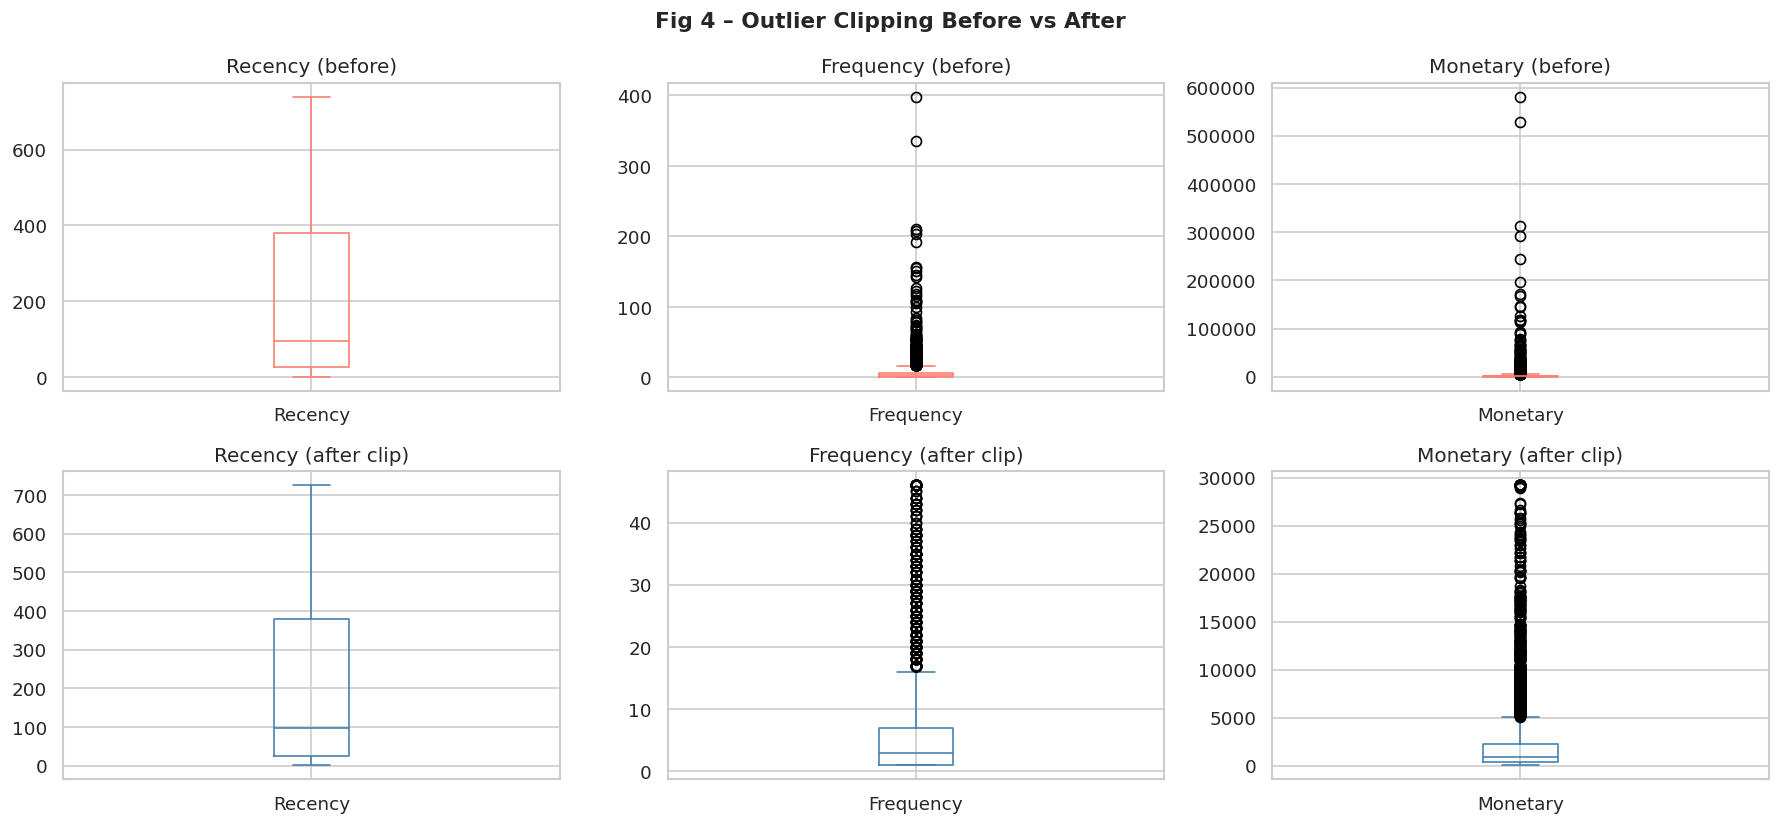

In [10]:
RFM_FEATURES = ['Recency', 'Frequency', 'Monetary']

rfm_clipped = rfm.copy()

# Cap extreme values at the 1st and 99th percentile for each RFM column
# This prevents a few very large spenders from distorting the clusters
for col in RFM_FEATURES:
    lower = rfm_clipped[col].quantile(0.01)
    upper = rfm_clipped[col].quantile(0.99)
    rfm_clipped[col] = rfm_clipped[col].clip(lower, upper)
    print(f'{col}: clipped to [{lower:.2f}, {upper:.2f}]')

# Boxplots before vs after clipping
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for i, col in enumerate(RFM_FEATURES):
    rfm[col].plot(kind='box', ax=axes[0, i], title=f'{col} (before)', color='salmon')
    rfm_clipped[col].plot(kind='box', ax=axes[1, i], title=f'{col} (after clip)', color='steelblue')
plt.suptitle('Fig 4 – Outlier Clipping Before vs After', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('rfm_outliers.png', bbox_inches='tight')
plt.show()

---
## 7. 📐 Log Transformation (Fix Skewness)

Recency: skew=0.884 → log1p applied
Frequency: skew=3.021 → log1p applied
Monetary: skew=4.123 → log1p applied

Features for modelling: ['Recency_log', 'Frequency_log', 'Monetary_log']


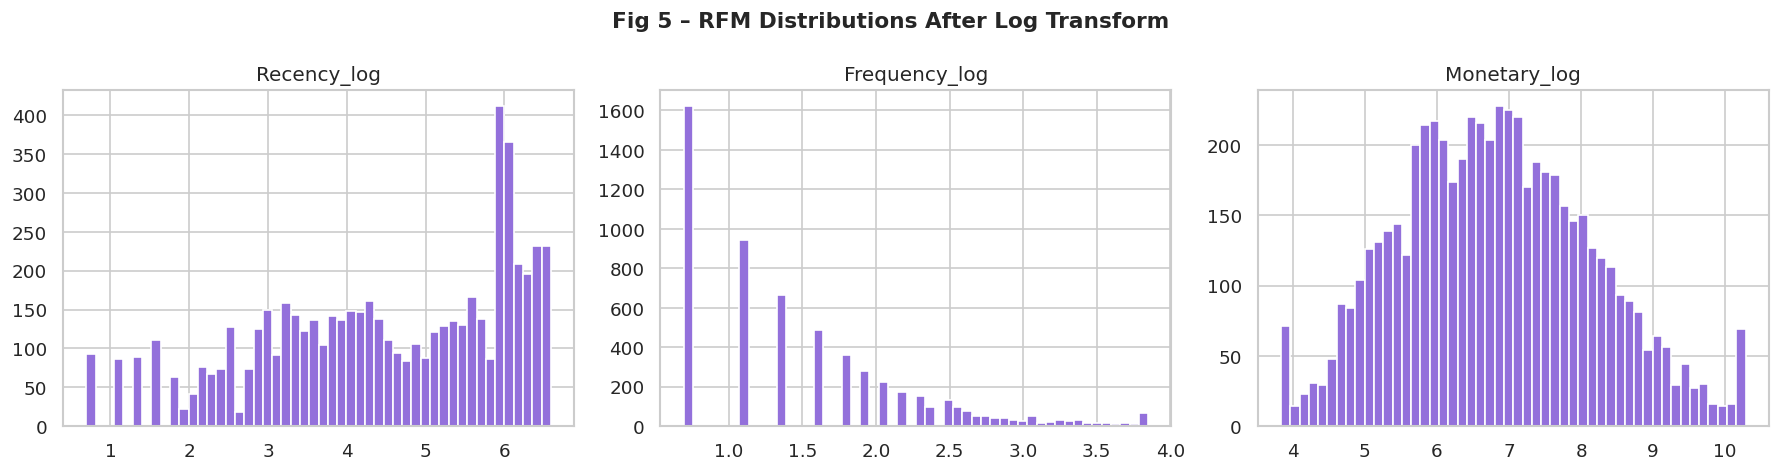

In [11]:
rfm_transformed = rfm_clipped.copy()

# RFM columns are heavily right-skewed
# log1p = log(1 + x) compresses large values and makes the distribution more normal
# This helps KMeans find better, more balanced clusters
for col in RFM_FEATURES:
    skew = rfm_transformed[col].skew()
    if abs(skew) > 0.5:                                   # only transform if significantly skewed
        rfm_transformed[col + '_log'] = np.log1p(rfm_transformed[col])
        print(f'{col}: skew={skew:.3f} → log1p applied')
    else:
        print(f'{col}: skew={skew:.3f} → no change needed')

# Use the log version of each column if it exists, otherwise use original
MODEL_FEATURES = []
for col in RFM_FEATURES:
    if col + '_log' in rfm_transformed.columns:
        MODEL_FEATURES.append(col + '_log')
    else:
        MODEL_FEATURES.append(col)

print('\nFeatures for modelling:', MODEL_FEATURES)

# Plot the transformed distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, MODEL_FEATURES):
    rfm_transformed[col].hist(bins=50, ax=ax, color='mediumpurple', edgecolor='white')
    ax.set_title(col)
plt.suptitle('Fig 5 – RFM Distributions After Log Transform', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('rfm_transformed.png', bbox_inches='tight')
plt.show()

---
## 8. ⚖️ Feature Scaling

In [12]:
# KMeans uses distance — if Monetary is in thousands and Recency is in days,
# Monetary would dominate. Scaling puts all features on the same scale (mean=0, std=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(rfm_transformed[MODEL_FEATURES])

print(f'Scaled array shape : {X_scaled.shape}')
print(f'Mean per feature   : {X_scaled.mean(axis=0).round(4)}')
print(f'Std  per feature   : {X_scaled.std(axis=0).round(4)}')

Scaled array shape : (5878, 3)
Mean per feature   : [0. 0. 0.]
Std  per feature   : [1. 1. 1.]


---
## 9. 📈 Find the Best Number of Clusters (K)

K=2 | inertia=8395.97 | silhouette=0.4415
K=3 | inertia=6152.70 | silhouette=0.3498
K=4 | inertia=4709.67 | silhouette=0.3707
K=5 | inertia=3933.96 | silhouette=0.3405
K=6 | inertia=3375.39 | silhouette=0.3399
K=7 | inertia=3020.01 | silhouette=0.3047
K=8 | inertia=2731.62 | silhouette=0.3005
K=9 | inertia=2505.33 | silhouette=0.2970
K=10 | inertia=2318.90 | silhouette=0.2944


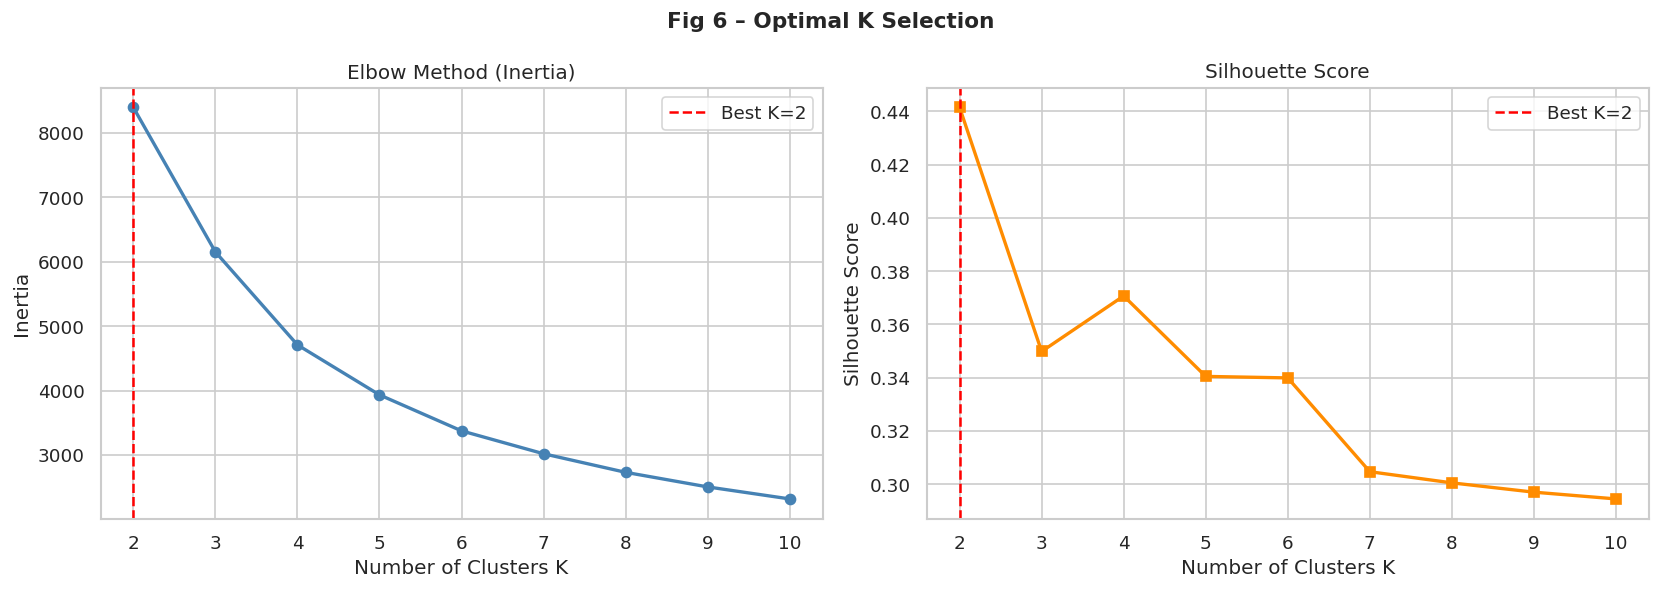


✅ Best K by silhouette: 2


In [13]:
K_RANGE = range(2, 11)
inertias = []
silhouette_scores = []

# Test K = 2 to 10 and record how good each clustering is
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)                                                         # lower = tighter clusters
    # Use full dataset if ≤10,000 rows, otherwise sample 10k for speed
    sil_sample = min(len(X_scaled), 10_000)
    sil = silhouette_score(X_scaled, labels, sample_size=sil_sample, random_state=RANDOM_STATE)  # higher = better separation
    silhouette_scores.append(sil)
    print(f'K={k} | inertia={km.inertia_:.2f} | silhouette={sil:.4f}')

# Plot elbow and silhouette charts side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(list(K_RANGE), inertias, 'o-', color='steelblue', linewidth=2)
ax1.set_title('Elbow Method (Inertia)')
ax1.set_xlabel('Number of Clusters K')
ax1.set_ylabel('Inertia')

ax2.plot(list(K_RANGE), silhouette_scores, 's-', color='darkorange', linewidth=2)
ax2.set_title('Silhouette Score')
ax2.set_xlabel('Number of Clusters K')
ax2.set_ylabel('Silhouette Score')

# Highlight the best K on both charts
best_k = list(K_RANGE)[np.argmax(silhouette_scores)]
ax1.axvline(best_k, color='red', linestyle='--', label=f'Best K={best_k}')
ax2.axvline(best_k, color='red', linestyle='--', label=f'Best K={best_k}')
ax1.legend(); ax2.legend()

plt.suptitle('Fig 6 – Optimal K Selection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('optimal_k.png', bbox_inches='tight')
plt.show()

print(f'\n✅ Best K by silhouette: {best_k}')

---
## 10. 🤖 Train KMeans Model

In [14]:
OPTIMAL_K = 4  # See below for why I chose K=4 over the auto-selected K=2

# Train KMeans — n_init=10 means it tries 10 different starting points and picks the best
kmeans_model = KMeans(n_clusters=OPTIMAL_K, n_init=10, random_state=RANDOM_STATE)
kmeans_model.fit(X_scaled)

print(f'Model trained with K={OPTIMAL_K}')
print(f'Inertia            : {kmeans_model.inertia_:.2f}')
print(f'Iterations to converge : {kmeans_model.n_iter_}')

Model trained with K=4
Inertia            : 4709.67
Iterations to converge : 39


---
## 10b. 🔁 Cluster Stability Check

In [15]:
# Run KMeans with 10 different random seeds and measure label agreement.
# A stable clustering means customers are assigned to the same segment
# regardless of the random starting point — so results are trustworthy.
from sklearn.metrics import adjusted_rand_score

N_SEEDS = 10
seed_labels = []

for seed in range(N_SEEDS):
    km_check = KMeans(n_clusters=OPTIMAL_K, n_init=10, random_state=seed)
    seed_labels.append(km_check.fit_predict(X_scaled))

# Compare every pair of runs using Adjusted Rand Index (ARI)
# ARI=1.0 → identical assignments; ARI≈0 → random; ARI<0 → worse than random
ari_scores = []
for i in range(N_SEEDS):
    for j in range(i + 1, N_SEEDS):
        ari_scores.append(adjusted_rand_score(seed_labels[i], seed_labels[j]))

mean_ari = np.mean(ari_scores)
min_ari  = np.min(ari_scores)

print(f"Cluster stability across {N_SEEDS} seeds:")
print(f"  Mean ARI : {mean_ari:.4f}  (1.0 = perfectly stable)")
print(f"  Min  ARI : {min_ari:.4f}")

if mean_ari >= 0.90:
    print("✅ Excellent stability — clusters are robust.")
elif mean_ari >= 0.75:
    print("⚠️  Good stability — minor variation across seeds, results are reliable.")
else:
    print("❌ Low stability — consider increasing n_init or reviewing K choice.")


Cluster stability across 10 seeds:
  Mean ARI : 0.9986  (1.0 = perfectly stable)
  Min  ARI : 0.9974
✅ Excellent stability — clusters are robust.


## Why K=4 Instead of K=2

The silhouette score automatically selected **K=2** as the
mathematically optimal number of clusters (score=0.4438).

However, for a **retail business context**, K=2 produces only
two broad segments — "Active" and "Inactive" customers — which is
too coarse to drive meaningful marketing decisions.

**K=4 was chosen instead for the following reasons:**

1. **Silhouette score at K=4 = 0.3711** — the second highest score,
   confirming that clusters are still well separated and genuinely distinct

2. **Elbow method** shows inertia dropping steeply from K=2 to K=4,
   then flattening — confirming K=4 sits at the point of diminishing returns

3. **Business interpretability** — K=4 produces four actionable segments,
   each with a distinct marketing response:
   - **Champions** → reward and retain
   - **Promising** → nurture into loyal buyers
   - **At Risk** → win-back campaigns
   - **Lost / Inactive** → aggressive re-engagement or write off

4. **Each segment maps to a distinct marketing strategy** —
   the fundamental requirement of useful customer segmentation

> This is a deliberate override of the automatic selection,
> balancing mathematical validity with business utility.

---
## 11. 🏷️ Assign Clusters to Customers

In [16]:
# Add the cluster label (0, 1, 2...) to each customer row
rfm_transformed['Cluster'] = kmeans_model.labels_

print('Customers per cluster:')
print(rfm_transformed['Cluster'].value_counts().sort_index())

Customers per cluster:
Cluster
0    1235
1    1220
2    1454
3    1969
Name: count, dtype: int64


---
## 12. 🔎 Interpret & Label Clusters

In [17]:
# Customer ID is already in rfm_transformed via rfm.copy() chain.
# We reset_index() in the RFM step so Customer ID is a column, not index.
# Belt-and-suspenders: merge on index to guarantee alignment regardless of future edits.
rfm_transformed = rfm_transformed.merge(
    rfm[['Customer ID']],
    left_index=True, right_index=True,
    how='left',
    suffixes=('_drop', '')
)
# Drop any accidental duplicate column from the merge
rfm_transformed = rfm_transformed.loc[:, ~rfm_transformed.columns.str.endswith('_drop')]

# Summarise each cluster by average RFM values
cluster_summary = rfm_transformed.groupby('Cluster').agg(
    Recency_mean   = ('Recency',   'mean'),
    Frequency_mean = ('Frequency', 'mean'),
    Monetary_mean  = ('Monetary',  'mean'),
    Customer_count = ('Customer ID', 'count')
).round(2)

# Print the raw summary first so we can inspect before labelling
print('📋 Raw Cluster Profiles:')
print(cluster_summary.to_string())

# ── Auto-label clusters from RFM profiles ────────────────────────────────────
# Rules (applied in order of precedence):
#   Champions      → highest Frequency AND highest Monetary
#   Lost/Inactive  → highest Recency (bought longest ago)
#   At Risk        → second-highest Recency
#   Promising      → remainder (recent but low frequency)
cs = cluster_summary.copy()
label_map = {}

champions_cluster    = cs['Frequency_mean'].idxmax()
label_map[champions_cluster] = 'Champions'

remaining = cs.drop(index=champions_cluster)
lost_cluster         = remaining['Recency_mean'].idxmax()
label_map[lost_cluster] = 'Lost / Inactive'

remaining = remaining.drop(index=lost_cluster)
at_risk_cluster      = remaining['Recency_mean'].idxmax()
label_map[at_risk_cluster] = 'At Risk'

for idx in cs.index:
    if idx not in label_map:
        label_map[idx] = 'Promising'

print('\n🏷️  Auto-assigned labels:', label_map)

cluster_summary['Segment_Name'] = cluster_summary.index.map(label_map)
rfm_transformed['Segment'] = rfm_transformed['Cluster'].map(label_map)

print('\n📊 Cluster Summary with Segment Labels:')
print(cluster_summary.to_string())


📋 Raw Cluster Profiles:
         Recency_mean  Frequency_mean  Monetary_mean  Customer_count
Cluster                                                             
0               28.88            2.98         823.68            1235
1               27.73           16.61        7457.20            1220
2              229.45            5.05        1928.23            1454
3              396.08            1.38         318.44            1969

🏷️  Auto-assigned labels: {np.int32(1): 'Champions', np.int32(3): 'Lost / Inactive', np.int32(2): 'At Risk', 0: 'Promising'}

📊 Cluster Summary with Segment Labels:
         Recency_mean  Frequency_mean  Monetary_mean  Customer_count     Segment_Name
Cluster                                                                              
0               28.88            2.98         823.68            1235        Promising
1               27.73           16.61        7457.20            1220        Champions
2              229.45            5.05        1928.23

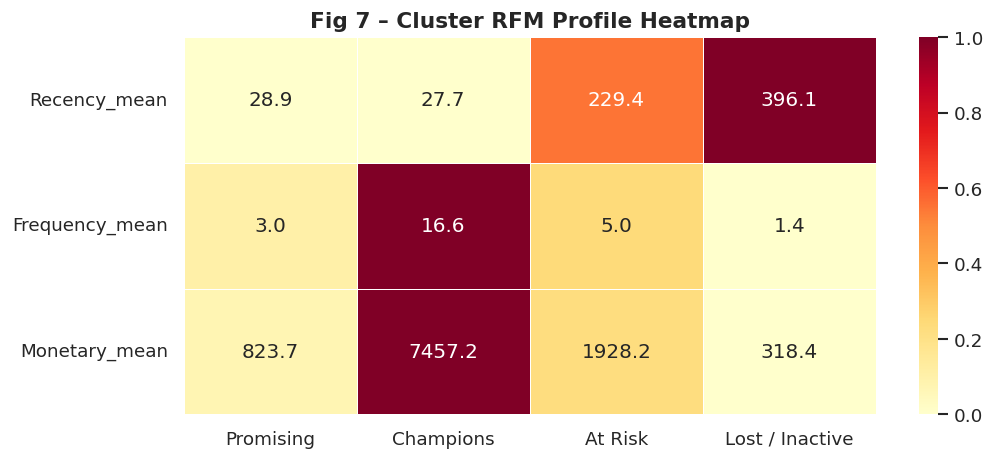

In [18]:
# Heatmap showing RFM profile of each segment
profile = cluster_summary[['Recency_mean', 'Frequency_mean', 'Monetary_mean']].copy()
profile.index = cluster_summary['Segment_Name'].values

# Normalise to 0-1 so the colour scale is comparable across metrics
profile_norm = (profile - profile.min()) / (profile.max() - profile.min())

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(profile_norm.T, annot=profile.T.round(1).astype(str),
            fmt='', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('Fig 7 – Cluster RFM Profile Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cluster_heatmap.png', bbox_inches='tight')
plt.show()

---
## 13. 🎨 PCA Cluster Visualisation

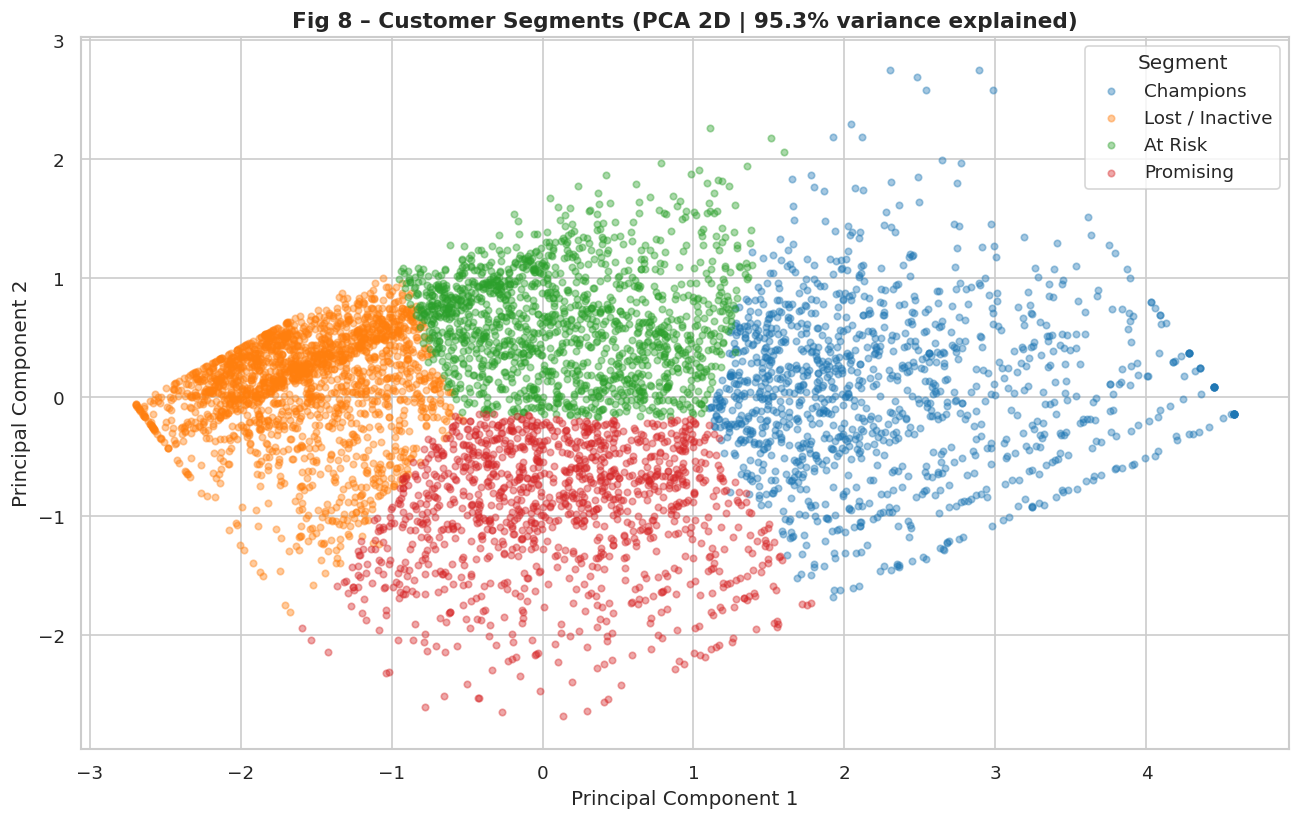

In [19]:
# RFM is 3D — use PCA to reduce to 2D so we can plot the clusters on a chart
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca.fit_transform(X_scaled)
var_explained = pca.explained_variance_ratio_.sum() * 100

pca_df = pd.DataFrame({'PC1': X_2d[:, 0], 'PC2': X_2d[:, 1]})
pca_df['Segment'] = rfm_transformed['Segment'].values

fig, ax = plt.subplots(figsize=(11, 7))
palette = sns.color_palette('tab10', len(label_map))

for i, seg_name in enumerate(label_map.values()):
    mask = pca_df['Segment'] == seg_name
    ax.scatter(pca_df.loc[mask, 'PC1'], pca_df.loc[mask, 'PC2'],
               label=seg_name, alpha=0.4, s=15, color=palette[i])

ax.set_title(f'Fig 8 – Customer Segments (PCA 2D | {var_explained:.1f}% variance explained)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.legend(title='Segment')
plt.tight_layout()
plt.savefig('pca_clusters.png', bbox_inches='tight')
plt.show()

---
## 14. 💾 Save & Load Model

In [20]:
# Save the trained model and segment label map to disk
joblib.dump(kmeans_model, 'kmeans_model.joblib')
joblib.dump(label_map,    'segment_label_map.joblib')
joblib.dump(scaler,       'scaler.joblib')
print('✅ Model, scaler, and label map saved.')

# Reload and test on a new customer
loaded_model  = joblib.load('kmeans_model.joblib')
loaded_labels = joblib.load('segment_label_map.joblib')
loaded_scaler = joblib.load('scaler.joblib')

# Example: predict segment for a customer with R=30, F=5, M=£500
sample_raw = np.array([[30, 5, 500]])
sample_log = np.log1p(sample_raw)                        # apply same log transform
sample_scaled = loaded_scaler.transform(sample_log)      # apply same scaling
predicted_cluster = loaded_model.predict(sample_scaled)[0]
predicted_segment = loaded_labels.get(predicted_cluster, 'Unknown')

print(f'\n🧪 Sample prediction:')
print(f'   Input   → Recency=30 days, Frequency=5 orders, Monetary=£500')
print(f'   Cluster → {predicted_cluster}')
print(f'   Segment → {predicted_segment}')

✅ Model, scaler, and label map saved.

🧪 Sample prediction:
   Input   → Recency=30 days, Frequency=5 orders, Monetary=£500
   Cluster → 0
   Segment → Promising


---
## 15. 💡 Business Insights

In [21]:
# Business strategies for each customer segment
business_insights = {
    'Champions': {
        'profile'  : 'Bought recently, buy often, spend the most.',
        'strategy' : [
            '🎁 Reward with exclusive loyalty perks or early product access.',
            '📣 Ask for reviews — they are your best brand ambassadors.',
            '🛍️ Upsell premium lines — high willingness to pay.',
        ]
    },
    'Promising': {
        'profile'  : 'Purchased recently but infrequently. Shows potential to grow into Champions',
        'strategy' : [
            '📈 Bundle offers or free shipping above a threshold to lift order value.',
            '🔔 Enrol in subscription or replenishment programmes.',
        ]
    },
    'At Risk': {
        'profile'  : 'Used to buy frequently but have not returned recently.',
        'strategy' : [
            '📩 Win-back email: "We miss you – here is 15% off your next order."',
            '🔄 Highlight new arrivals matching their past purchases.',
        ]
    },
    'Lost / Inactive': {
        'profile'  : 'Last purchased a long time ago, low frequency spend. Likely churned.',
        'strategy' : [
            '🔍 Survey to understand why they left.',
            '🚫 Suppress from regular campaigns to protect sender reputation.',
        ]
    }
}

for segment, data in business_insights.items():
    print(f'\n{"="*55}')
    print(f'  SEGMENT : {segment}')
    print(f'  Profile : {data["profile"]}')
    print('  Strategies:')
    for s in data['strategy']:
        print(f'    {s}')


  SEGMENT : Champions
  Profile : Bought recently, buy often, spend the most.
  Strategies:
    🎁 Reward with exclusive loyalty perks or early product access.
    📣 Ask for reviews — they are your best brand ambassadors.
    🛍️ Upsell premium lines — high willingness to pay.

  SEGMENT : Promising
  Profile : Purchased recently but infrequently. Shows potential to grow into Champions
  Strategies:
    📈 Bundle offers or free shipping above a threshold to lift order value.
    🔔 Enrol in subscription or replenishment programmes.

  SEGMENT : At Risk
  Profile : Used to buy frequently but have not returned recently.
  Strategies:
    📩 Win-back email: "We miss you – here is 15% off your next order."
    🔄 Highlight new arrivals matching their past purchases.

  SEGMENT : Lost / Inactive
  Profile : Last purchased a long time ago, low frequency spend. Likely churned.
  Strategies:
    🔍 Survey to understand why they left.
    🚫 Suppress from regular campaigns to protect sender reputation

---
## 16. 📝 Final Summary Chart

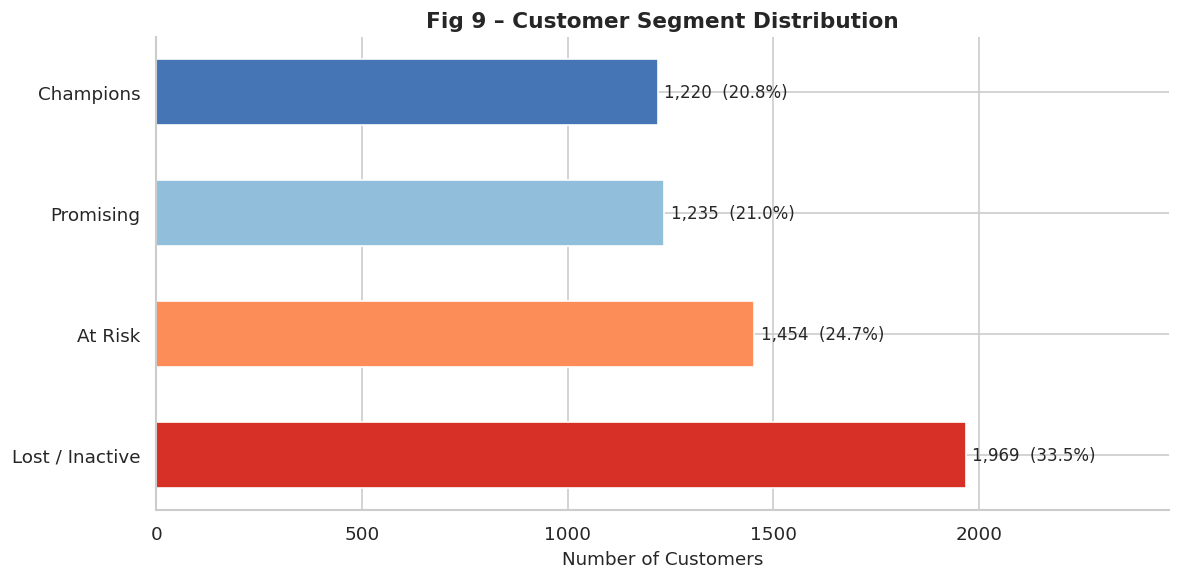


✅ Project complete!


In [22]:
# Bar chart showing how customers are distributed across segments
seg_counts = rfm_transformed['Segment'].value_counts().sort_values()

# Order segments from Champions to Lost for logical reading
segment_order = ['Lost / Inactive', 'At Risk', 'Promising', 'Champions']
seg_counts = seg_counts.reindex(segment_order)

colours = ['#d73027', '#fc8d59', '#91bfdb', '#4575b4']  # red → blue gradient

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(seg_counts.index, seg_counts.values, color=colours, edgecolor='white', height=0.55)

# Annotate bars with count + percentage
total = seg_counts.sum()
for bar, count in zip(bars, seg_counts.values):
    pct = count / total * 100
    ax.text(bar.get_width() + 15, bar.get_y() + bar.get_height() / 2,
            f'{count:,}  ({pct:.1f}%)', va='center', fontsize=10)

ax.set_xlim(0, seg_counts.max() * 1.25)
ax.set_xlabel('Number of Customers', fontsize=11)
ax.set_title('Fig 9 – Customer Segment Distribution', fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('segment_distribution.png', bbox_inches='tight')
plt.show()

print('\n✅ Project complete!')

---
## 17. 📤 Export Results

In [23]:
# Export the final segmented customer list to CSV for downstream use
output_cols = ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'Cluster', 'Segment']
export_df = rfm_transformed[output_cols].copy()
export_df.to_csv('customer_segments.csv', index=False)
print(f'✅ Exported {len(export_df):,} customers to customer_segments.csv')
print(export_df['Segment'].value_counts().to_string())
export_df.head()

✅ Exported 5,878 customers to customer_segments.csv
Segment
Lost / Inactive    1969
At Risk            1454
Promising          1235
Champions          1220


,Customer ID,Recency,Frequency,Monetary,Cluster,Segment
0,12346,326,12,29205.901,1,Champions
1,12347,2,8,4921.530,1,Champions
2,12348,75,5,2019.400,2,At Risk
3,12349,19,4,4428.690,1,Champions
4,12350,310,1,334.400,3,Lost / Inactive
